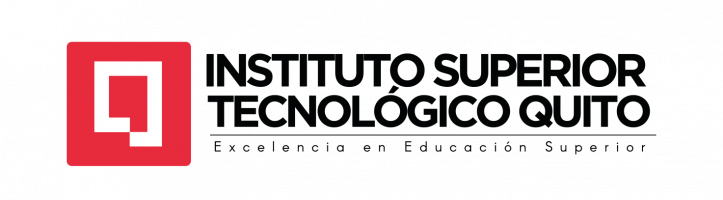

## 01PAO26-26 - Variables cualitativas

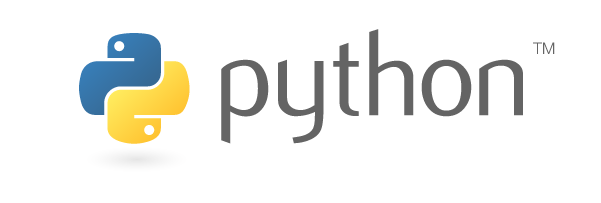

*Byron Armando Melo Aguilar*

*[Enlace a Github](https://github.com/ByronMN911/practicas-machine-learning-I/tree/main/Parcial%20III/Tarea%202)*

In [9]:
#Variables cuantitativas discretas: números finitos contables (números enteros | 0 y 1)
#Variables cuantitativas continuas: números infinitos decimales (cualquier número real)

In [10]:
# Creación aleatoria de datos
import numpy as np
X = np.array([0.5, 23, 0.3, 4.5, 0.3, 0.5,
              -28, -50, 60, -100, -10, -11, 13, 19, 1, 9])
print(X)

[   0.5   23.     0.3    4.5    0.3    0.5  -28.   -50.    60.  -100.
  -10.   -11.    13.    19.     1.     9. ]


In [12]:
# Medidas de tendencia central
from scipy import stats
media = np.mean(X)a
mediana = np.median(X)
moda, _ = stats.mode(X)
print('media: ', media)
print('mediana: ', mediana)
print('moda :', moda)

media:  -4.24375
mediana:  0.5
moda : 0.3


In [23]:
# MEDIDAS DE POSICIÓN (CUARTILES Y RANGO INTERCUARTÍLICO)

import numpy as np
import matplotlib.pyplot as plt

# Calcular el primer cuartil (Q1).
# Corresponde al percentil 25, es decir, el 25% de los datos
# son menores o iguales a este valor.
Q1 = np.percentile(X, 25)

# Calcular el tercer cuartil (Q3).
# Corresponde al percentil 75, lo que significa que el 75% de los datos
# son menores o iguales a este valor.
Q3 = np.percentile(X, 75)

# Calcular el Rango Intercuartílico (RIC o IQR).
# El RIC representa la amplitud del 50% central de los datos,
# es decir, la distancia entre el tercer y el primer cuartil.
RIC = Q3 - Q1

# Calcular el límite inferior para detectar valores atípicos (outliers).
# Todo dato menor a este límite se considera un posible valor atípico.
# La constante 1.5 es el criterio más utilizado en estadística
# para identificar outliers mediante el Rango Intercuartílico.
lim_inf = Q1 - 1.5 * RIC

# Calcular el límite superior para detectar valores atípicos.
# Todo dato mayor a este límite se considera un posible valor atípico.
lim_sup = Q3 + 1.5 * RIC

# Mostrar el valor del Rango Intercuartílico.
print("RIC:", RIC)

# Mostrar el límite inferior.
print("Límite inferior:", lim_inf)

# Mostrar el límite superior.
print("Límite superior:", lim_sup)

# Interpretación:
# - Si un dato es menor que el límite inferior, se considera un posible outlier.
# - Si un dato es mayor que el límite superior, también se considera un posible outlier.
# - Los datos comprendidos entre ambos límites se consideran valores normales
#   según el criterio del Rango Intercuartílico.

RIC: 3.3999999999999995
Límite inferior: -3.3999999999999995
Límite superior: 10.2


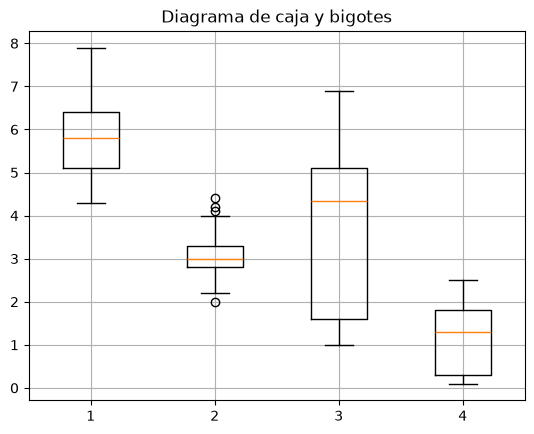

In [22]:
# Dibujar un diagrama de caja y bigotes (Boxplot).
# Este gráfico resume la distribución de los datos y permite identificar
# visualmente la dispersión, la posición de la mediana y los posibles valores atípicos.
plt.boxplot(X)

# Agregar una cuadrícula para facilitar la lectura del gráfico.
plt.grid()

# Agregar un título descriptivo al gráfico.
plt.title("Diagrama de caja y bigotes")

# Mostrar el gráfico en pantalla.
plt.show()

# Interpretación del diagrama de caja y bigotes:
#
# - La caja representa el 50% central de los datos, comprendido entre
#   el primer cuartil (Q1) y el tercer cuartil (Q3).
#
# - La línea horizontal ubicada dentro de la caja corresponde a la mediana
#   (percentil 50), que divide los datos en dos mitades.
#
# - Los "bigotes" se extienden hasta los valores mínimo y máximo que no
#   son considerados valores atípicos.
#
# - Los puntos que aparecen fuera de los bigotes representan los valores
#   atípicos (outliers), es decir, observaciones que se encuentran por
#   debajo del límite inferior o por encima del límite superior calculados
#   mediante el Rango Intercuartílico (RIC).
#
# Nota:
# En el boxplot de Matplotlib, la línea central representa la mediana,
# no la media. La media únicamente se muestra si se utiliza el parámetro
# showmeans=True.

In [24]:
# MEDIDAS DE DISPERSIÓN

# Calcular la desviación estándar (o desviación típica) de los datos.
# La desviación estándar indica, en promedio, qué tan alejados se
# encuentran los datos respecto a la media.
#
# Un valor pequeño significa que los datos están muy concentrados
# alrededor de la media, mientras que un valor grande indica que
# los datos están más dispersos.
desvest = np.std(X)

# Mostrar el valor de la desviación estándar.
print("Desviación típica:", desvest)

# Calcular la varianza.
# La varianza es el cuadrado de la desviación estándar y representa
# el grado de dispersión de los datos respecto a la media.
#
# Matemáticamente:
# Varianza = (Desviación estándar)²
#
# También podría calcularse directamente con:
# np.var(X)
print("Varianza:", desvest**2)

Desviación típica: 1.9738430577598278
Varianza: 3.896056416666667


In [16]:
# Medidas de distribución
asimetria = stats.skew(X)
curtosis = stats.kurtosis(X, fisher=True) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.kurtosis.html
print('Asimetría ', np.round(asimetria, 4))
print('Curtosis ', np.round(curtosis, 4))

if curtosis>0:
    print('Distribución Leptocúrtica')
elif curtosis<0:
    print('Distribución Platicúrtica')
else:
    print('Distribución Mesocúrtica')

Asimetría  -1.1302
Curtosis  2.2858
Distribución Leptocúrtica


In [35]:
import pandas as pd
import scipy.stats as stats
from sklearn import datasets

# 1. Cargar el set de datos de Iris
iris = datasets.load_iris()

# 2. Crear un DataFrame con nombres claros para no confundir las columnas
columnas = ['largo_sepalo', 'ancho_sepalo', 'largo_petalo', 'ancho_petalo']
df = pd.DataFrame(iris.data, columns=columnas)

# Las especies (target)
y = iris.target

print("--- Vista previa de los datos ---")
display(df.head()) # Si no usas Jupyter Notebook, cambia 'display' por 'print'


# -------------------------------------------------------------------------
# PREGUNTA 1: ¿Qué tipo de asimetría se observa en la "longitud del pétalo"?
# -------------------------------------------------------------------------
# Extraemos SOLO la columna de la longitud del pétalo
largo_petalo = df['largo_petalo']

# Calculamos la asimetría (skewness)
asimetria = stats.skew(largo_petalo)

print(f"\n--- ASIMETRÍA (Longitud del Pétalo) ---")
print(f"El valor calculado es: {asimetria:.4f}")

if asimetria > 0:
    print('Tipo de asimetría: Asimetría Positiva (sesgo hacia la derecha)')
elif asimetria < 0:
    print('Tipo de asimetría: Asimetría Negativa (sesgo hacia la izquierda)')
else:
    print('Tipo de asimetría: Simétrica perfecta')


# -------------------------------------------------------------------------
# PREGUNTA 2: ¿A qué tipo de distribución se ajusta el "ancho del sépalo"?
# -------------------------------------------------------------------------
# Extraemos SOLO la columna del ancho del sépalo
ancho_sepalo = df['ancho_sepalo']

# Calculamos la curtosis (fisher=True establece la normal en 0)
curtosis = stats.kurtosis(ancho_sepalo, fisher=True)

print(f"\n--- CURTOSIS (Ancho del Sépalo) ---")
print(f"El valor calculado es: {curtosis:.4f}")

if curtosis > 0:
    print('Tipo de distribución: Leptocúrtica')
elif curtosis < 0:
    print('Tipo de distribución: Platicúrtica')
else:
    print('Tipo de distribución: Mesocúrtica')

--- Vista previa de los datos ---


,largo_sepalo,ancho_sepalo,largo_petalo,ancho_petalo
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



--- ASIMETRÍA (Longitud del Pétalo) ---
El valor calculado es: -0.2721
Tipo de asimetría: Asimetría Negativa (sesgo hacia la izquierda)

--- CURTOSIS (Ancho del Sépalo) ---
El valor calculado es: 0.1810
Tipo de distribución: Leptocúrtica


In [29]:
# Respuesta a las preguntas sobre asimetría y curtosis del dataset Iris
petal_length = X[:, 2]
sepal_width = X[:, 1]

asim_petal = stats.skew(petal_length)
curt_sepal_width = stats.kurtosis(sepal_width, fisher=True)

print('Asimetría (longitud del pétalo):', np.round(asim_petal, 4))
if asim_petal < 0:
    print('La variable presenta una asimetría negativa (sesgo hacia la izquierda).')
elif asim_petal > 0:
    print('La variable presenta una asimetría positiva (sesgo hacia la derecha).')
else:
    print('La variable es simétrica.')

print('Curtosis (ancho del sépalo):', np.round(curt_sepal_width, 4))
if curt_sepal_width > 0:
    print('La distribución es leptocúrtica.')
elif curt_sepal_width < 0:
    print('La distribución es platicúrtica.')
else:
    print('La distribución es mesocúrtica.')

Asimetría (longitud del pétalo): -0.2721
La variable presenta una asimetría negativa (sesgo hacia la izquierda).
Curtosis (ancho del sépalo): 0.181
La distribución es leptocúrtica.


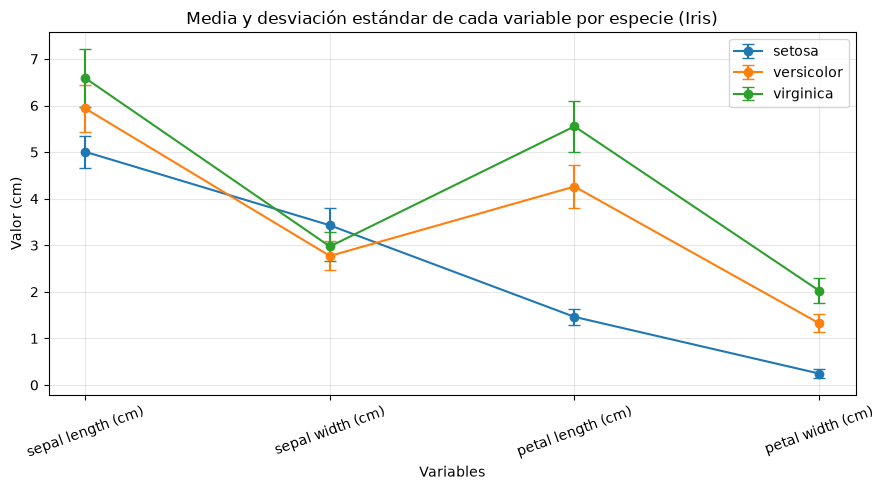

In [19]:
# EJERCICIO EXTRA SOBRE EL DATASET DE IRIS
# Extraer la media y la desviación típica de cada variable en función de la clase y representarlo en un gráfico (plt.errorbar)
feature_names = iris.feature_names
target_names = iris.target_names
colors = ['tab:blue', 'tab:orange', 'tab:green']

plt.figure(figsize=(9,5))
for i, name in enumerate(target_names):
    mask = (y == i)
    means = X[mask].mean(axis=0)
    stds = X[mask].std(axis=0)
    plt.errorbar(feature_names, means, yerr=stds, marker='o', capsize=4,
                 label=name, color=colors[i])

plt.title('Media y desviación estándar de cada variable por especie (Iris)')
plt.xlabel('Variables')
plt.ylabel('Valor (cm)')
plt.xticks(rotation=20)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El resultado debería ser algo como esto: